# Наивный Байес (Naive Bayes)

## 1. Название и краткая информация о сдаваемом методе (1 абзац)

**Наивный Байес (Naive Bayes)** — это вероятностный метод классификации, основанный на **теореме Байеса** (формула для пересчёта вероятности события с учётом новой информации). Метод называется «наивным», потому что предполагает **условную независимость признаков** при фиксированном классе: считается, что значение одного признака никак не зависит от других. Несмотря на сильное упрощение, метод часто даёт хорошее качество, очень быстро обучается и требует мало данных. Для каждого объекта модель вычисляет вероятность принадлежности к каждому классу и относит объект к классу с **наибольшей** апостериорной вероятностью (вероятностью после учёта признаков). В этом ноутбуке используется вариант **Gaussian Naive Bayes** (читается «гауссов наивный Байес») из библиотеки `scikit-learn` — он применяется, когда признаки числовые и предполагается, что внутри каждого класса они распределены по нормальному (гауссовому) закону.

## 2. Блок с используемыми библиотеками

Короткие пояснения к названиям:
- **numpy** — численные операции с массивами.
- **pandas** — таблицы (DataFrame, читается «дата-фрейм») и удобная работа с данными.
- **matplotlib** — базовая библиотека графиков.
- **seaborn** (читается «сиборн») — красивые статистические графики поверх matplotlib (в т.ч. тепловая карта).
- **scikit-learn** (читается «сайкит-лёрн») — библиотека машинного обучения: готовые датасеты, модели и метрики.
- **GaussianNB** — реализация наивного Байеса для числовых признаков с предположением о нормальном распределении.

In [1]:
# !pip -q install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Набор данных и вспомогательные инструменты
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

# Сама модель: наивный Байес для числовых (непрерывных) признаков
from sklearn.naive_bayes import GaussianNB

# Метрики качества
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Для повторяемости результатов (одинаковое разбиение при каждом запуске)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

## 3. Блок с описанием и демонстрацией (частичной распечаткой) используемого датасета

В качестве примера возьмём встроенный датасет **Wine** из `scikit-learn`. Это классическая задача классификации: по 13 числовым признакам (результаты химического анализа) нужно определить **сорт вина** — один из трёх классов (`class_0`, `class_1`, `class_2`). Датасет небольшой (178 объектов), полностью числовой и не требует скачивания.

In [2]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")        # числовая метка класса: 0, 1, 2
target_names = list(data.target_names)             # ['class_0', 'class_1', 'class_2']

df = X.copy()
df["target"] = y

print("Размерность датасета (строки, столбцы):", df.shape)
print("Имена классов:", target_names)
print("\nРаспределение классов (сколько объектов каждого сорта):")
print(y.value_counts().sort_index())

print("\nПервые 5 строк датасета:")
display(df.head(5))

print("\nОписательная статистика по признакам (часть):")
display(df.describe().T.head(10))

Размерность датасета (строки, столбцы): (178, 14)
Имена классов: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Распределение классов (сколько объектов каждого сорта):
target
0    59
1    71
2    48
Name: count, dtype: int64

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Описательная статистика по признакам (часть):


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Пояснение к таблицам:** каждая строка — одно вино, каждый столбец — числовой признак (например, `alcohol` — содержание алкоголя, `malic_acid` — яблочная кислота и т.д.), а столбец `target` — это правильный ответ (сорт).

## 4. Блок с предварительной обработкой датасета

Что делаем:
1. Проверяем **пропуски** (пустые значения) и **дубликаты** (повторяющиеся строки).
2. Разделяем данные на **обучающую** и **тестовую** выборки. Обучающая нужна, чтобы модель «училась», тестовая — чтобы честно проверить её качество на тех данных, которых она не видела.
3. Выполняем **стандартизацию** признаков (StandardScaler — приводит каждое числовое поле к нулевому среднему и единичному разбросу). Для `GaussianNB` это не обязательно, но полезная общая практика, и это делает наглядной тепловую карту, графики и визуализацию границы решений.

In [3]:
# 1) Пропуски
missing = df.isna().sum().sort_values(ascending=False)
print("Пропуски по каждому столбцу (если везде 0 — пропусков нет):")
print(missing.head(10))

# 2) Дубликаты
dup_count = df.duplicated().sum()
print("\nКоличество полностью совпадающих строк (дубликатов):", dup_count)

# 3) Разделение на признаки (X) и цель (y) уже сделано выше.
# Разобьём на train/test с сохранением долей классов (stratify).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 4) Стандартизация: обучаем scaler ТОЛЬКО на train и применяем к test,
#    чтобы не было "подглядывания" в тестовые данные.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Оформим обратно в DataFrame — так удобнее смотреть
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nРазмеры выборок:")
print("X_train:", X_train_scaled.shape, "| X_test:", X_test_scaled.shape)
print("\nДоли классов в обучающей выборке:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nДоли классов в тестовой выборке:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nПервые строки обучающей выборки после стандартизации:")
display(X_train_scaled.head(5))

Пропуски по каждому столбцу (если везде 0 — пропусков нет):
alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
dtype: int64

Количество полностью совпадающих строк (дубликатов): 0

Размеры выборок:
X_train: (142, 13) | X_test: (36, 13)

Доли классов в обучающей выборке:
target
0    0.330986
1    0.401408
2    0.267606
Name: proportion, dtype: float64

Доли классов в тестовой выборке:
target
0    0.333333
1    0.388889
2    0.277778
Name: proportion, dtype: float64

Первые строки обучающей выборки после стандартизации:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,0.385801,-0.637871,1.776668,-1.224532,0.696430,0.526865,0.732292,-0.169549,-0.415783,-0.167467,0.624378,0.252908,0.467725
30,0.948519,-0.765445,1.253174,0.853284,0.091785,1.172795,1.333181,-0.590457,1.349742,0.305303,1.067155,0.151048,1.815768
26,0.523354,-0.519409,0.954034,-1.046433,-0.445678,0.930572,1.006382,-0.169549,-0.260002,-0.081509,-0.128343,0.893172,1.516203
12,0.973529,-0.555859,0.168793,-1.076116,-0.714409,0.526865,0.816627,-0.590457,0.363125,0.262324,0.890044,0.427526,1.932265
148,0.435820,0.820120,0.056615,0.556453,-0.512860,-0.555068,-1.291756,0.756449,-0.606183,1.474335,-1.766619,-1.435059,-0.297831


## 5. Блок с тепловой картой

Тепловая карта (heatmap — «карта тепла») корреляций показывает, **насколько сильно связаны** друг с другом признаки. Значение корреляции изменяется от -1 до 1:
- около 1 — сильная прямая связь (растёт один — растёт другой),
- около -1 — сильная обратная связь,
- около 0 — связи почти нет.

Наивный Байес предполагает **независимость** признаков, поэтому очень сильные корреляции — сигнал, что это предположение нарушается. Но на практике метод часто всё равно работает хорошо.

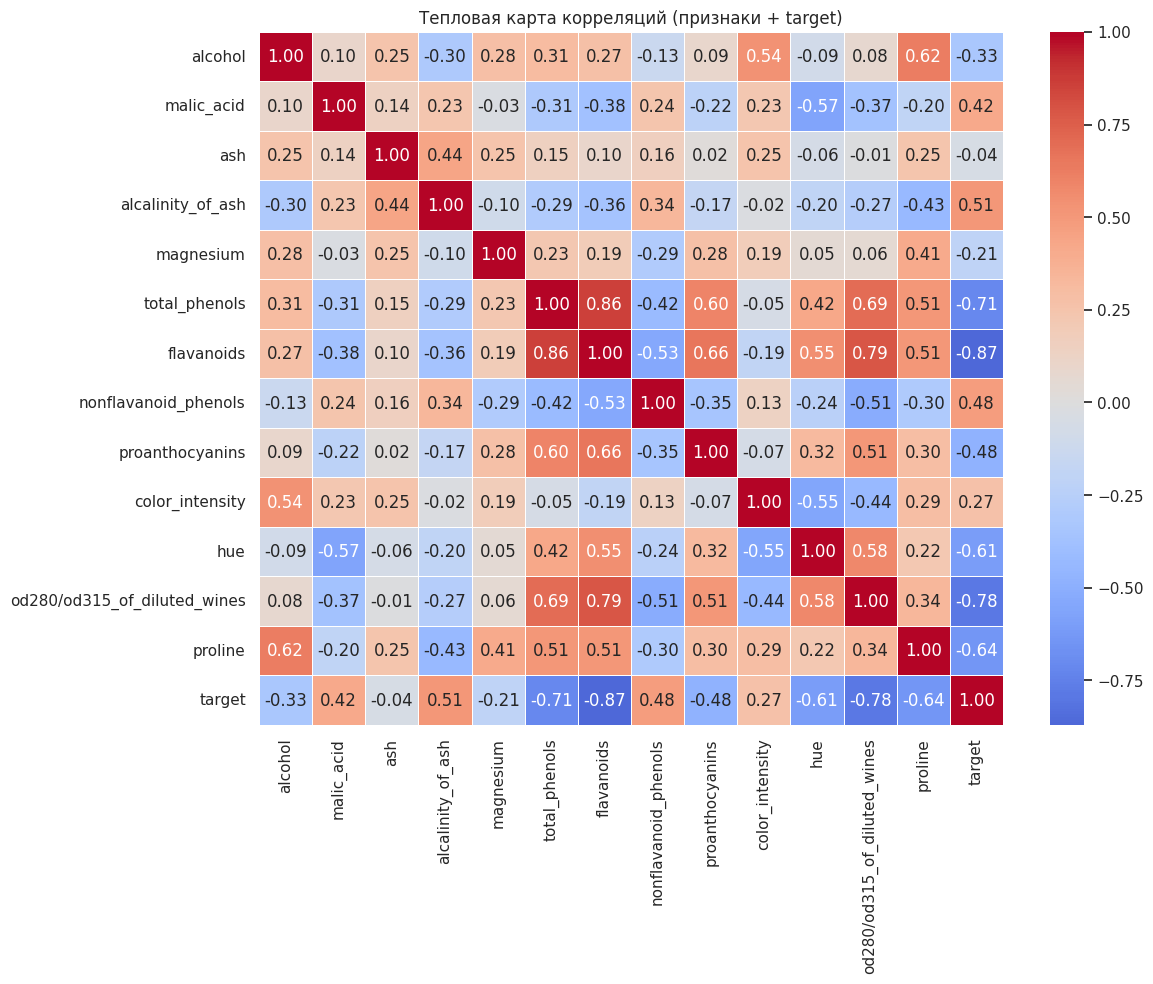

Корреляции признаков с target (по убыванию модуля):
flavanoids                     -0.870180
od280/od315_of_diluted_wines   -0.784280
total_phenols                  -0.713752
proline                        -0.638823
hue                            -0.605732
alcalinity_of_ash               0.507562
proanthocyanins                -0.481488
nonflavanoid_phenols            0.476767
malic_acid                      0.418279
alcohol                        -0.331843
color_intensity                 0.268592
magnesium                      -0.207569
ash                            -0.044951
Name: target, dtype: float64


In [4]:
# Корреляции считаем по обучающей выборке вместе с целевой переменной,
# чтобы увидеть и связи между признаками, и связь каждого признака с target.
train_full = X_train.copy()
train_full["target"] = y_train

corr = train_full.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,        # подписываем значения
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.5,
)
plt.title("Тепловая карта корреляций (признаки + target)")
plt.show()

print("Корреляции признаков с target (по убыванию модуля):")
print(corr["target"].drop("target").reindex(corr["target"].drop("target").abs().sort_values(ascending=False).index))

## 6. Блок с обучением модели

Обучаем **GaussianNB** — наивный Байес с предположением, что признаки внутри каждого класса распределены по нормальному закону. Модель оценивает для каждого класса два числа на каждый признак: **среднее** и **дисперсию** (разброс), и затем использует их, чтобы посчитать вероятности.

Для надёжности дополнительно проверим модель **кросс-валидацией** (cross-validation — «перекрёстная проверка»): обучающая выборка разбивается на 5 частей, модель 5 раз обучается и проверяется на разных частях. Это даёт более честную оценку качества, чем один замер.

In [5]:
model = GaussianNB()

# Кросс-валидация на обучающей выборке (5 частей)
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

print("Точности на 5 частях кросс-валидации:", np.round(cv_scores, 4))
print(f"Средняя точность по кросс-валидации: {cv_scores.mean():.4f}")
print(f"Стандартное отклонение:              {cv_scores.std():.4f}")

# Обучаем модель на всей обучающей выборке
model.fit(X_train_scaled, y_train)
print("\nМодель обучена.")

# Посмотрим ключевые параметры, которые модель выучила
print("\nОцененные априорные вероятности классов (class_prior_):")
print(pd.Series(model.class_prior_, index=[f"класс {c}" for c in model.classes_]).round(4))

print("\nСредние значения признаков для каждого класса (theta_):")
display(pd.DataFrame(model.theta_, index=[f"класс {c}" for c in model.classes_], columns=X.columns).round(3))

Точности на 5 частях кросс-валидации: [1.     0.931  1.     0.9286 1.    ]
Средняя точность по кросс-валидации: 0.9719
Стандартное отклонение:              0.0344

Модель обучена.

Оцененные априорные вероятности классов (class_prior_):
класс 0    0.3310
класс 1    0.4014
класс 2    0.2676
dtype: float64

Средние значения признаков для каждого класса (theta_):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
класс 0,0.913,-0.252,0.345,-0.736,0.453,0.885,0.997,-0.540,0.481,0.210,0.434,0.771,1.175
класс 1,-0.868,-0.388,-0.482,0.238,-0.349,-0.088,0.027,-0.025,0.131,-0.862,0.448,0.235,-0.710
класс 2,0.173,0.893,0.297,0.553,-0.037,-0.963,-1.274,0.705,-0.792,1.034,-1.208,-1.306,-0.388


## 7. Блок с прогнозами модели

Делаем прогнозы на тестовой выборке. Считаем:
- **accuracy** (точность — доля правильных ответов),
- **classification report** (подробный отчёт: precision, recall, F1 для каждого класса — подробное описание в markdown ниже),
- **confusion matrix** (матрица ошибок: кто с кем путается),
- **ROC-AUC** в варианте «один-против-остальных» (One-vs-Rest) — обобщение метрики ROC-AUC на случай трёх классов.

In [6]:
# 1) Метки (какой класс предсказала модель)
y_pred = model.predict(X_test_scaled)

# 2) Вероятности каждого класса для каждого объекта
y_proba = model.predict_proba(X_test_scaled)

# 3) Точность
acc = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке (accuracy): {acc:.4f}")

# 4) Отчёт по классификации
print("\nОтчёт по классификации (precision / recall / f1-score по каждому классу):")
print(classification_report(y_test, y_pred, target_names=target_names))

# 5) Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок (строки — истина, столбцы — прогноз):")
print(pd.DataFrame(cm, index=[f"истина: {n}" for n in target_names],
                        columns=[f"прогноз: {n}" for n in target_names]))

# 6) ROC-AUC для мультикласса (One-vs-Rest)
auc_ovr = roc_auc_score(y_test, y_proba, multi_class="ovr")
print(f"\nROC-AUC (один-против-остальных, среднее): {auc_ovr:.4f}")

# 7) Частичная распечатка прогнозов: истина, прогноз и вероятности
preview = pd.DataFrame({
    "истина": y_test.values,
    "прогноз": y_pred,
    "P(class_0)": y_proba[:, 0].round(3),
    "P(class_1)": y_proba[:, 1].round(3),
    "P(class_2)": y_proba[:, 2].round(3),
}).reset_index(drop=True)

print("\nПервые 15 прогнозов (с вероятностями классов):")
display(preview.head(15))

Точность на тестовой выборке (accuracy): 0.9722

Отчёт по классификации (precision / recall / f1-score по каждому классу):
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Матрица ошибок (строки — истина, столбцы — прогноз):
                 прогноз: class_0  прогноз: class_1  прогноз: class_2
истина: class_0                12                 0                 0
истина: class_1                 1                13                 0
истина: class_2                 0                 0                10

ROC-AUC (один-против-остальных, среднее): 1.0000

Первые 15 прогнозов (с вероятностями классов):


,истина,прогноз,P(class_0),P(class_1),P(class_2)
0,0,0,1.000,0.000,0.000
1,2,2,0.000,0.000,1.000
2,0,0,1.000,0.000,0.000
3,1,1,0.000,1.000,0.000
4,1,1,0.000,1.000,0.000
5,0,0,1.000,0.000,0.000
6,0,0,1.000,0.000,0.000
7,1,0,0.569,0.431,0.000
8,1,1,0.000,1.000,0.000
9,2,2,0.000,0.000,1.000


**Пояснение терминов в отчёте:**
- **precision** (точность по классу) — из всех объектов, которым модель поставила этот класс, какая доля действительно этого класса.
- **recall** (полнота) — из всех объектов этого класса, какую долю модель нашла.
- **f1-score** — гармоническое среднее precision и recall; общая оценка по классу.
- **support** — сколько объектов этого класса в тестовой выборке.
- **ROC-AUC** — площадь под ROC-кривой; чем ближе к 1, тем лучше модель различает классы.

## 8. Блок с графиками выходных результатов

Построим:
1. **Матрицу ошибок** в виде тепловой карты.
2. **ROC-кривые** для каждого класса (один-против-остальных).
3. **Сравнение распределений** самого информативного признака по классам (так визуально видна «наивная» идея Байеса).
4. **Границу решений** на плоскости PCA (метод главных компонент — способ сжать 13 признаков в 2 для картинки).

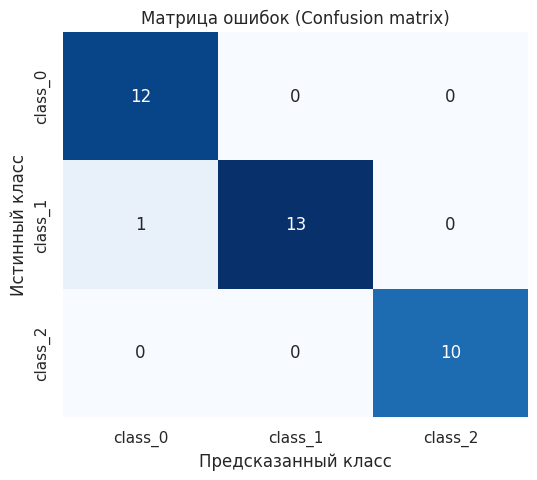

In [7]:
# 8.1 Матрица ошибок как тепловая карта
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Матрица ошибок (Confusion matrix)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

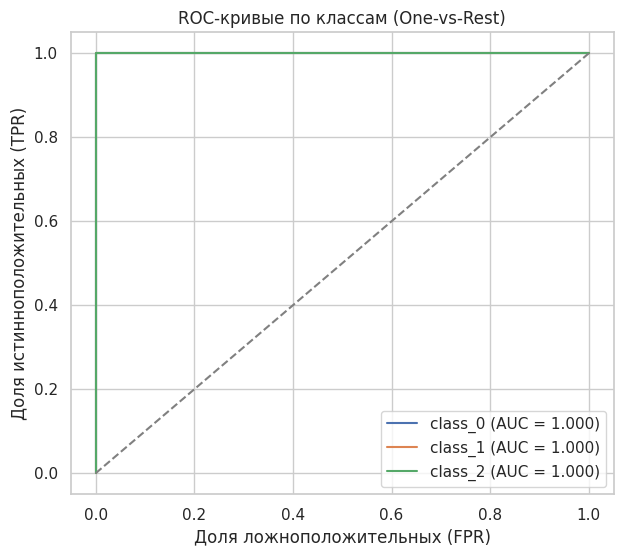

In [8]:
# 8.2 ROC-кривые для каждого класса (один-против-остальных)
classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)  # one-hot представление истинных меток

plt.figure(figsize=(7, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f"{target_names[i]} (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # линия случайного классификатора
plt.xlabel("Доля ложноположительных (FPR)")
plt.ylabel("Доля истинноположительных (TPR)")
plt.title("ROC-кривые по классам (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

3 самых информативных признака по модулю корреляции с target: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols']


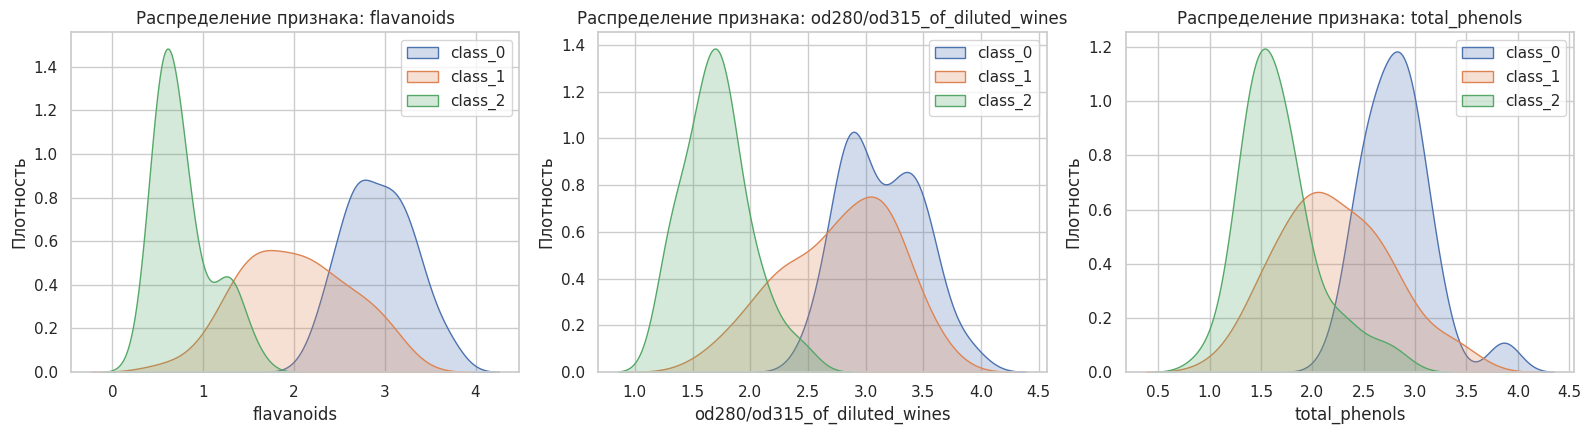

In [9]:
# 8.3 Распределения самых сильных признаков по классам
# Наивный Байес по сути смотрит именно на такие распределения: чем сильнее они различаются по классам,
# тем лучше признак помогает разделять классы.

# Выберем 3 признака с самой большой по модулю корреляцией с target
top_features = (
    corr["target"].drop("target").abs().sort_values(ascending=False).head(3).index.tolist()
)
print("3 самых информативных признака по модулю корреляции с target:", top_features)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
train_full_named = train_full.copy()
train_full_named["класс"] = train_full_named["target"].map({i: n for i, n in enumerate(target_names)})

for ax, feat in zip(axes, top_features):
    for name in target_names:
        subset = train_full_named.loc[train_full_named["класс"] == name, feat]
        sns.kdeplot(subset, ax=ax, label=name, fill=True, alpha=0.25)
    ax.set_title(f"Распределение признака: {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Плотность")
    ax.legend()

plt.tight_layout()
plt.show()

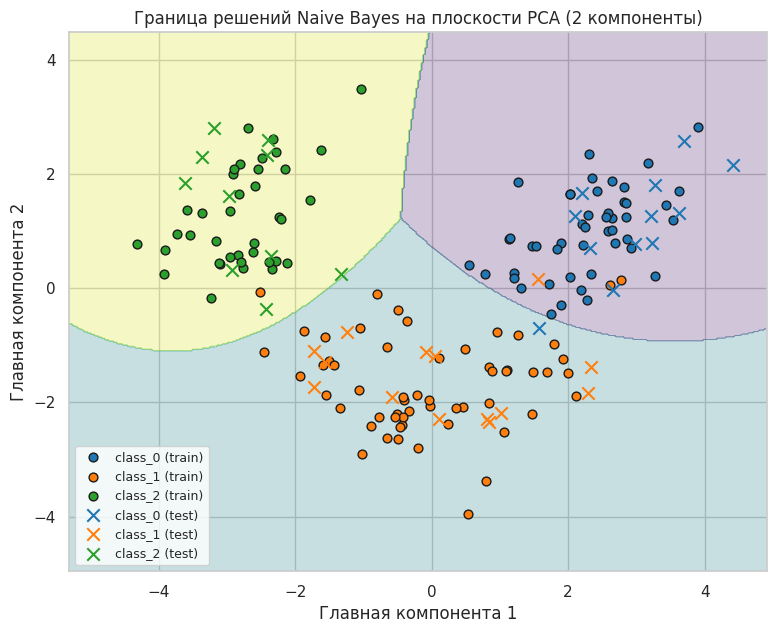

Доля объяснённой дисперсии двумя компонентами PCA: 0.551


In [10]:
# 8.4 Граница решений на плоскости PCA (метод главных компонент)
# PCA сжимает 13 признаков в 2, чтобы можно было нарисовать картинку.
# Обучим отдельную копию GaussianNB на этих 2 компонентах — только для визуализации.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = GaussianNB()
model_pca.fit(X_train_pca, y_train)

# Сетка точек, чтобы закрасить области классов
x_min = X_train_pca[:, 0].min() - 1
x_max = X_train_pca[:, 0].max() + 1
y_min = X_train_pca[:, 1].min() - 1
y_max = X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_pca.predict(grid).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, cls in enumerate(np.unique(y_train)):
    mask = y_train.values == cls
    plt.scatter(
        X_train_pca[mask, 0], X_train_pca[mask, 1],
        s=40, c=colors[i], edgecolor="k",
        label=f"{target_names[i]} (train)"
    )

# Тестовые точки — крестиками
for i, cls in enumerate(np.unique(y_test)):
    mask = y_test.values == cls
    plt.scatter(
        X_test_pca[mask, 0], X_test_pca[mask, 1],
        s=80, c=colors[i], marker="x",
        label=f"{target_names[i]} (test)"
    )

plt.title("Граница решений Naive Bayes на плоскости PCA (2 компоненты)")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.legend(loc="best", fontsize=9)
plt.grid(True)
plt.show()

print(f"Доля объяснённой дисперсии двумя компонентами PCA: {pca.explained_variance_ratio_.sum():.3f}")

---

### Короткий вывод

Модель **Gaussian Naive Bayes** обучена на датасете Wine и показывает высокую точность классификации трёх сортов вина по 13 химическим признакам. Кросс-валидация подтверждает устойчивость результата. Графики показывают:
- матрицу ошибок (где именно модель путается между классами),
- ROC-кривые (как хорошо разделяются классы по вероятностям),
- распределения ключевых признаков по классам (на этом и основан наивный Байес),
- границу решений на плоскости PCA (визуальное представление того, как модель «разрезает» пространство признаков).

Несмотря на сильное предположение о независимости признаков, метод даёт хорошее качество и при этом очень быстро обучается — это одна из его главных практических сильных сторон.